In [16]:
import pandas as pd

df = pd.read_excel('iris_clean.xlsx')
df

,sepal.length,sepal.width,petal.length,petal.width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


演習問題1

In [17]:
from sklearn.model_selection import train_test_split

x = df.drop(['species'],axis = 1)
y = df['species']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.7, test_size=0.3, random_state=0)

In [18]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=3)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

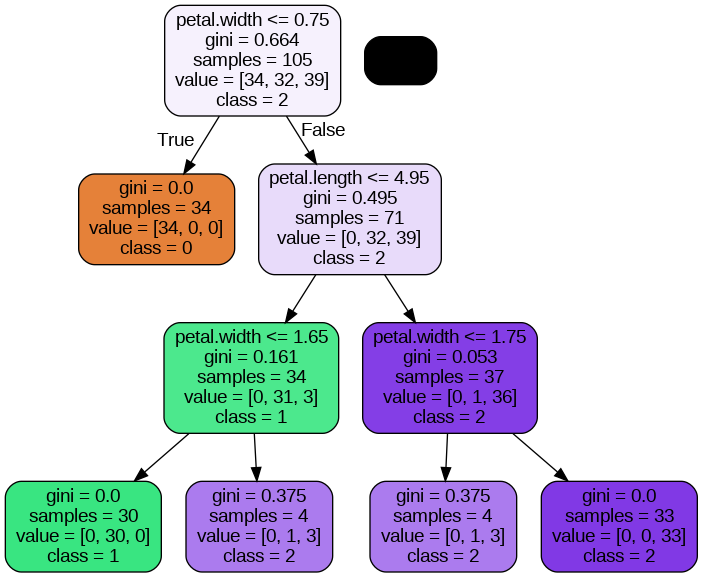

In [19]:
from sklearn.tree import export_graphviz
import pydotplus
from six import StringIO
from IPython.display import Image

dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                feature_names=x_train.columns,
                class_names=['0','1','2'],
                filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Text(0, 0.5, 'feature')

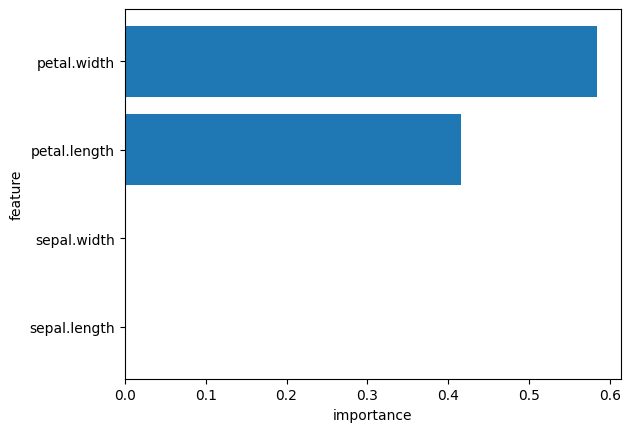

In [20]:
import numpy as np
from matplotlib import pyplot as plt

n_features = len(x_train.columns)
plt.barh(range(n_features), model.feature_importances_, align = 'center')
plt.yticks(np.arange(n_features), x_train.columns)
plt.xlabel("importance")
plt.ylabel("feature")

花びらの長さと幅が分類に大きく影響しており、がく片の長さと幅は役に立たない説明変数

In [21]:
print('正解率(train):{:.3f}'.format(model.score(x_train, y_train)))
print('正解率(test);{:.3f}'.format(model.score(x_test, y_test)))

正解率(train):0.981
正解率(test);0.978


演習問題2

In [22]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)
model.predict(x_test)

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0])

45個のテストデータの予測結果

In [23]:
print('正解率(train):{:.3f}'.format(model.score(x_train, y_train)))
print('正解率(test);{:.3f}'.format(model.score(x_test, y_test)))

正解率(train):1.000
正解率(test);0.978


学習データの正解率は決定木よりも上がったが、テストデータの正解率はどちらの分類器も同じだった